In [12]:
#CELL 1 — Import & Load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score)
from sklearn.feature_selection import mutual_info_classif

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.shape

(7043, 21)

Data Cleaning

In [14]:
df.isna().sum().sum() #missing values in the data set

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [17]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [18]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
columns = df.columns
binary_cols = []

for col in columns:
    if df[col].value_counts().shape[0] == 2:
        binary_cols.append(col)

In [20]:
binary_cols # categorical features with two classes

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'Churn']

Variabel kategorikal yang tersisa memiliki lebih dari dua nilai atau kategori (kelas).

In [21]:
# Categorical features with multiple classes
multiple_cols_cat = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract','PaymentMethod']

#Binary categorical features
Lihat bagaimana penyebaran jumlah data pada setiap kategori dari variabel yang hanya memiliki dua kelas.

Exploratary Data Analyst (EDA)

C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\3603494130.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=df, ax=axes[0,0], palette=colors)
C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\3603494130.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="SeniorCitizen", data=df, ax=axes[0,1], palette=colors)
C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\3603494130.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Partner", data=df, ax=axes[0,2], palette=colors)
C:\Users\HP CORE I7\AppData\L

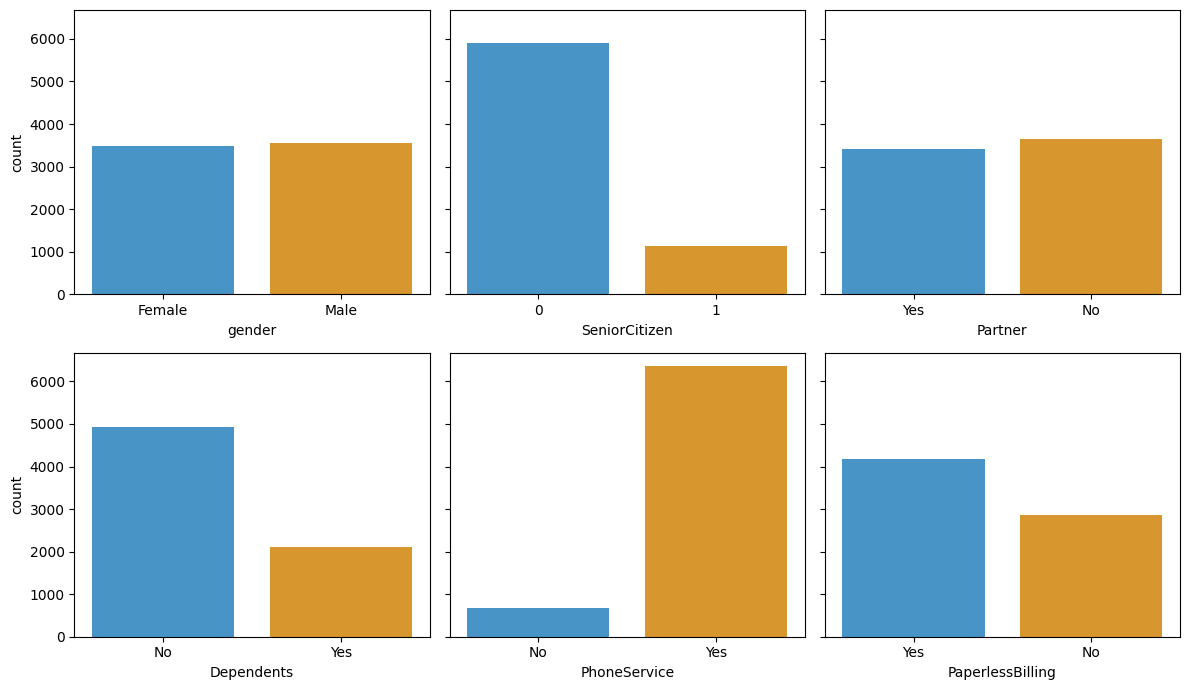

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(12,7), sharey=True)

colors = ["#3498DB", "#F39C12"]  # biru & oranye

sns.countplot(x="gender", data=df, ax=axes[0,0], palette=colors)
sns.countplot(x="SeniorCitizen", data=df, ax=axes[0,1], palette=colors)
sns.countplot(x="Partner", data=df, ax=axes[0,2], palette=colors)

sns.countplot(x="Dependents", data=df, ax=axes[1,0], palette=colors)
sns.countplot(x="PhoneService", data=df, ax=axes[1,1], palette=colors)
sns.countplot(x="PaperlessBilling", data=df, ax=axes[1,2], palette=colors)

plt.tight_layout()
plt.show()

Kesimpulan umum:

Berdasarkan distribusi fitur biner, dapat disimpulkan bahwa dataset memiliki distribusi yang cukup seimbang pada variabel gender dan partner, sedangkan variabel SeniorCitizen, Dependents, dan PhoneService menunjukkan ketidakseimbangan kelas yang cukup jelas. Mayoritas pelanggan merupakan non senior citizen, tidak memiliki tanggungan, dan menggunakan layanan telepon. Selain itu, penggunaan paperless billing juga lebih dominan dibandingkan metode penagihan tradisional.

Akan lebih baik jika kita memeriksa bagaimana variabel target (Churn) berubah berdasarkan fitur fitur biner. Agar dapat melakukan perhitungan, nilai pada variabel target perlu diubah terlebih dahulu. Nilai "Yes" akan dikonversi menjadi 1 dan "No" akan dikonversi menjadi 0.

In [23]:
churn_numeric = {'Yes':1, 'No':0}
df.Churn.replace(churn_numeric, inplace=True)

C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\3424737158.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Churn.replace(churn_numeric, inplace=True)
C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\3424737158.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Churn.replace(chu

In [24]:
df[['gender','Churn']].groupby(['gender']).mean()

,Churn
gender,
Female,0.269209
Male,0.261603


Rata rata tingkat churn pada pelanggan laki laki dan perempuan hampir sama. Hal ini menunjukkan bahwa variabel gender tidak memiliki kemampuan prediksi yang signifikan terhadap churn. Oleh karena itu, variabel gender tidak akan digunakan dalam model machine learning.

In [25]:
df[['SeniorCitizen','Churn']].groupby(['SeniorCitizen']).mean()

,Churn
SeniorCitizen,
0,0.236062
1,0.416813


In [26]:
df[['Partner','Churn']].groupby(['Partner']).mean()

,Churn
Partner,
No,0.329580
Yes,0.196649


In [27]:
df[['Dependents','Churn']].groupby(['Dependents']).mean()

,Churn
Dependents,
No,0.312791
Yes,0.154502


In [28]:
df[['PhoneService','Churn']].groupby(['PhoneService']).mean()

,Churn
PhoneService,
No,0.249267
Yes,0.267096


In [29]:
df[['PaperlessBilling','Churn']].groupby(['PaperlessBilling']).mean()

,Churn
PaperlessBilling,
No,0.163301
Yes,0.335651


Fitur biner lainnya menunjukkan adanya pengaruh terhadap variabel target (Churn). Variabel PhoneService sebenarnya juga dapat diabaikan apabila perbedaan tingkat churn sekitar 2% dianggap tidak cukup berarti. Namun, dalam analisis ini fitur tersebut tetap dipertahankan dan akan digunakan dalam model machine learning.

Selain itu, hubungan antara fitur dan variabel target juga dapat dianalisis menggunakan fungsi pivot_table() dari Pandas.

In [30]:
table = pd.pivot_table(df, values='Churn', index=['gender'],
                    columns=['SeniorCitizen'], aggfunc=np.mean)
table

C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\2321476923.py:1: FutureWarning: The provided callable <function mean at 0x000002631191E7A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  table = pd.pivot_table(df, values='Churn', index=['gender'],


SeniorCitizen,0,1
gender,,
Female,0.239384,0.422535
Male,0.232808,0.411150


In [31]:
table = pd.pivot_table(df, values='Churn', index=['Partner'],
                    columns=['Dependents'], aggfunc=np.mean)
table

C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\2606733739.py:1: FutureWarning: The provided callable <function mean at 0x000002631191E7A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  table = pd.pivot_table(df, values='Churn', index=['Partner'],


Dependents,No,Yes
Partner,,
No,0.342378,0.213296
Yes,0.254083,0.142367


Sekarang saatnya mengeksplorasi fitur kategorikal lainnya. Selain itu, kita juga memiliki fitur kontinu seperti tenure, MonthlyCharges, dan TotalCharges yang akan dibahas pada bagian berikutnya.

Terdapat enam variabel yang berkaitan dengan layanan internet. Variabel variabel tersebut hanya relevan jika pelanggan berlangganan layanan internet.

C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\3806188701.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


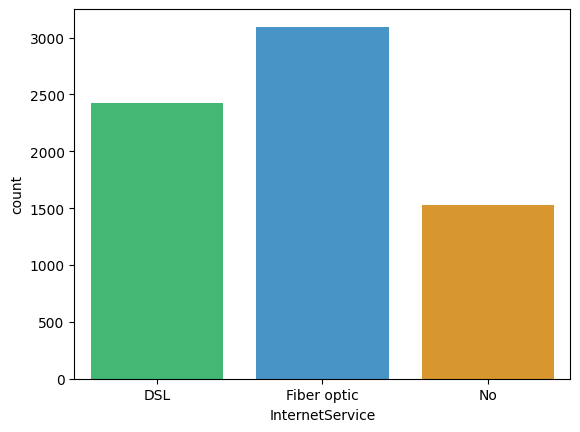

In [32]:
sns.countplot(
    data=df,
    x="InternetService",
    palette=["#2ECC71", "#3498DB", "#F39C12"]
)

plt.show()

In [33]:
df[['InternetService','Churn']].groupby('InternetService').mean()

,Churn
InternetService,
DSL,0.189591
Fiber optic,0.418928
No,0.074050


Variabel InternetService jelas merupakan faktor penting dalam memprediksi churn. Seperti yang terlihat, pelanggan yang menggunakan layanan internet Fiber Optic memiliki kecenderungan churn yang lebih tinggi dibandingkan pelanggan lainnya, meskipun jumlah pelanggan DSL dan Fiber Optic tidak berbeda jauh. Hal ini dapat mengindikasikan adanya masalah pada layanan Fiber Optic yang ditawarkan perusahaan. Namun, membuat asumsi hanya berdasarkan satu variabel bukanlah pendekatan yang baik. Oleh karena itu, perlu dilakukan analisis terhadap variabel lain, seperti MonthlyCharges.

In [34]:
df[['InternetService','MonthlyCharges']].groupby('InternetService').mean()

,MonthlyCharges
InternetService,
DSL,58.102169
Fiber optic,91.500129
No,21.079194


Fiber optic service itu lebih mahal dibandingkan DSL yang mungkin menjadi salah satu alasan kenapa customer churn.

C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\592084287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="StreamingTV", ax=axes[0,0], palette=colors)
C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\592084287.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="StreamingMovies", ax=axes[0,1], palette=colors)
C:\Users\HP CORE I7\AppData\Local\Temp\ipykernel_9548\592084287.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="OnlineSecurity", ax=axes[0,2], palette=colors)
C:\Users\HP CORE I

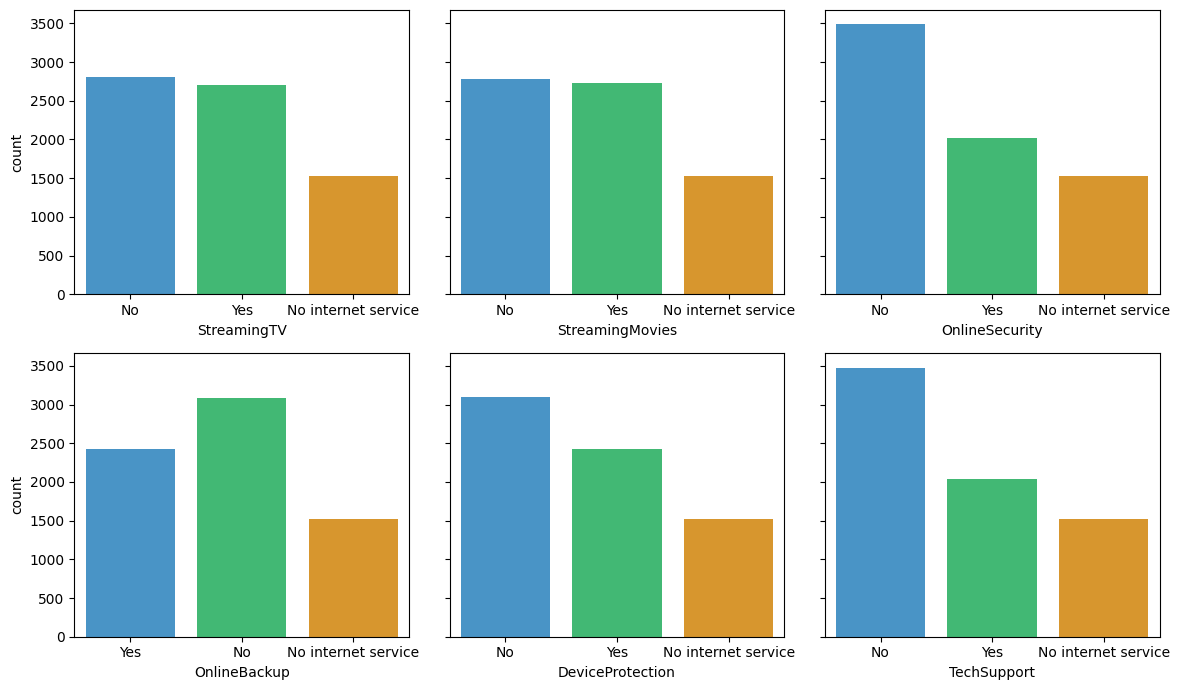

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)

colors = ["#3498DB", "#2ECC71", "#F39C12"]

sns.countplot(data=df, x="StreamingTV", ax=axes[0,0], palette=colors)
sns.countplot(data=df, x="StreamingMovies", ax=axes[0,1], palette=colors)
sns.countplot(data=df, x="OnlineSecurity", ax=axes[0,2], palette=colors)

sns.countplot(data=df, x="OnlineBackup", ax=axes[1,0], palette=colors)
sns.countplot(data=df, x="DeviceProtection", ax=axes[1,1], palette=colors)
sns.countplot(data=df, x="TechSupport", ax=axes[1,2], palette=colors)

plt.tight_layout()
plt.show()

In [36]:
df[['StreamingTV','Churn']].groupby('StreamingTV').mean()

,Churn
StreamingTV,
No,0.335231
No internet service,0.074050
Yes,0.300702


In [37]:
df[['StreamingMovies','Churn']].groupby('StreamingMovies').mean()

,Churn
StreamingMovies,
No,0.336804
No internet service,0.074050
Yes,0.299414


In [38]:
df[['OnlineSecurity','Churn']].groupby('OnlineSecurity').mean()

,Churn
OnlineSecurity,
No,0.417667
No internet service,0.074050
Yes,0.146112


In [39]:
df[['OnlineBackup','Churn']].groupby('OnlineBackup').mean()

,Churn
OnlineBackup,
No,0.399288
No internet service,0.074050
Yes,0.215315


In [40]:
df[['DeviceProtection','Churn']].groupby('DeviceProtection').mean()

,Churn
DeviceProtection,
No,0.391276
No internet service,0.074050
Yes,0.225021


In [41]:
df[['TechSupport','Churn']].groupby('TechSupport').mean()

,Churn
TechSupport,
No,0.416355
No internet service,0.074050
Yes,0.151663


Semua fitur yang berhubungan dengan layanan internet menunjukkan perbedaan tingkat churn antar kategori, sehingga fitur fitur tersebut berpotensi memiliki hubungan dengan keputusan pelanggan untuk berhenti berlangganan.

In [42]:
df[['Contract','Churn']].groupby('Contract').mean()

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


Seperti yang telah diperkirakan, pelanggan dengan kontrak jangka pendek memiliki kecenderungan lebih tinggi untuk melakukan churn. Temuan ini menjelaskan mengapa perusahaan berupaya membangun hubungan jangka panjang dengan pelanggannya.

In [43]:
df[['PaymentMethod','Churn']].groupby('PaymentMethod').mean()

,Churn
PaymentMethod,
Bank transfer (automatic),0.167098
Credit card (automatic),0.152431
Electronic check,0.452854
Mailed check,0.191067


Fitur kontinu dalam dataset ini adalah tenure, MonthlyCharges, dan TotalCharges. Nilai pada TotalCharges pada dasarnya merupakan hasil akumulasi dari biaya bulanan (MonthlyCharges) selama periode berlangganan (tenure). Oleh karena itu, fitur TotalCharges dianggap memiliki informasi yang mirip dengan kombinasi kedua variabel tersebut sehingga tidak perlu dimasukkan ke dalam model.
Menambahkan fitur yang tidak diperlukan dapat meningkatkan kompleksitas model. Jika memungkinkan, lebih baik menggunakan model yang lebih sederhana. Model yang terlalu kompleks cenderung mengalami overfitting, yaitu kondisi ketika model sangat baik dalam mempelajari data pelatihan tetapi kurang mampu melakukan prediksi pada data baru yang belum pernah dilihat sebelumnya. Karena tujuan utama machine learning adalah memprediksi atau menjelaskan data baru, overfitting menjadi masalah yang perlu dihindari.
Selanjutnya, distribusi dari fitur fitur kontinu akan dianalisis.

In [44]:
df[['tenure','MonthlyCharges','Churn']].groupby('Churn').mean()

,tenure,MonthlyCharges
Churn,,
0,37.569965,61.265124
1,17.979133,74.441332


Data ini jelas menunjukkan bahwa pelanggan yang sudah lama berlangganan cenderung tidak berhenti menggunakan layanan, sedangkan pelanggan yang keluar biasanya memiliki masa berlangganan yang lebih pendek sekitar 20 bulan dibanding yang bertahan, sehingga terlihat ada hubungan antara lama berlangganan dan kemungkinan churn.

Selain itu, biaya bulanan juga diduga berpengaruh terhadap keputusan pelanggan untuk berhenti, meskipun belum tentu menjadi penyebab langsung. Ada juga hubungan antara jenis kontrak dan lama berlangganan karena pelanggan dengan kontrak jangka panjang biasanya memang bertahan lebih lama.

Namun yang perlu diwaspadai adalah semua ini masih berupa korelasi, jadi belum bisa dipastikan mana yang benar benar menjadi penyebab utama churn karena bisa saja ada faktor lain yang tidak terlihat dalam data yang ikut memengaruhi hasil tersebut.

In [45]:
df[['Contract','tenure']].groupby('Contract').mean()

,tenure
Contract,
Month-to-month,18.036645
One year,42.044807
Two year,56.735103


Pelanggan dengan kontrak jangka panjang biasanya memang sudah menjadi pelanggan lebih lama, sedangkan pelanggan dengan kontrak pendek cenderung baru atau tidak lama berlangganan. Jadi kedua fitur ini membawa informasi yang hampir sama.

Setelah eksplore semua variable, kita telah memilih untuk tidak menggunakan variable berikut karena mereka hanya menambahkan dikit atau bahkan tidak sama sekali menambahkan kekuatan informasi untuk model:
1) Customer ID
2) Gender
3) PhoneService
4) Contract
5) TotalCharges

In [46]:
df.drop(['customerID','gender','PhoneService','Contract','TotalCharges'], axis=1, inplace=True)

In [47]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Yes,Electronic check,29.85,0
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,No,Mailed check,56.95,0
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Yes,Mailed check,53.85,1
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,No,Bank transfer (automatic),42.30,0
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Yes,Electronic check,70.70,1


In [48]:
df.shape

(7043, 16)

Pertama, fitur kategorikal harus diubah menjadi angka karena model hanya bisa menghitung data numerik. Tapi di sini ada perbedaan penting: data kita bersifat nominal, bukan ordinal, artinya tidak ada urutan atau tingkatan. Contohnya, “DSL” dan “Fiber optic” tidak bisa dianggap salah satunya lebih tinggi atau lebih baik secara angka.

Kalau kita salah pakai encoding biasa seperti memberi label 1, 2, 3, itu bisa menimbulkan masalah karena model akan menganggap angka lebih besar berarti lebih penting, padahal sebenarnya tidak ada hubungan urutan. Ini adalah asumsi yang sering keliru dalam preprocessing.

Karena itu digunakan one hot encoding, yaitu setiap kategori dibuat menjadi kolom sendiri dengan nilai 0 atau 1. Dengan cara ini, tidak ada kategori yang dianggap lebih tinggi dari yang lain, sehingga lebih adil secara representasi data.

Lalu, untuk fitur numerik seperti pengeluaran bulanan atau total biaya, dilakukan scaling. Tujuannya supaya semua fitur berada pada skala yang seimbang. Kalau tidak, fitur dengan angka besar bisa mendominasi perhitungan model, bukan karena lebih penting secara makna, tapi hanya karena nilainya lebih besar.

Feature Engineering (Encoding dan Scaling)

In [49]:
from sklearn.preprocessing import MinMaxScaler
cat_features = ['SeniorCitizen', 'Partner', 'Dependents',
        'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
X = pd.get_dummies(df, columns=cat_features, drop_first=True)

sc_tenure = MinMaxScaler()
sc_monthly = MinMaxScaler()

X['tenure'] = sc_tenure.fit_transform(df[['tenure']])
X['MonthlyCharges'] = sc_monthly.fit_transform(df[['MonthlyCharges']])

X.shape

(7043, 26)

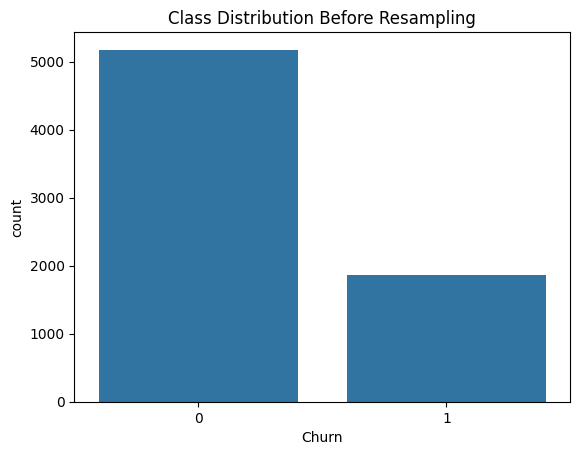

In [50]:
sns.countplot(x='Churn', data=df)
plt.title('Class Distribution Before Resampling')
plt.show()

In [51]:
X_no = X[X.Churn == 0]
X_yes = X[X.Churn == 1]

print(len(X_no),len(X_yes))

5174 1869


In [52]:
X_yes_upsampled = X_yes.sample(n=len(X_no), replace=True, random_state=42)
print(len(X_yes_upsampled))

5174


In [53]:
X_upsampled = pd.concat([X_no, X_yes_upsampled]).reset_index(drop=True)

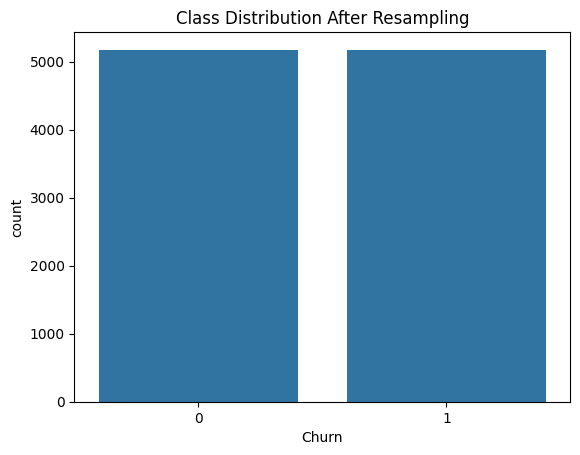

In [54]:
sns.countplot(x='Churn', data=X_upsampled)
plt.title('Class Distribution After Resampling')
plt.show()

In [55]:
X = X_upsampled.drop(['Churn'], axis=1) #features (independent variables)
y = X_upsampled['Churn'] #target (dependent variable)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)
print(f"Data Training: {X_train.shape}")
print(f"Data Testing: {X_test.shape}")

Data Training: (8278, 25)
Data Testing: (2070, 25)


Feature Selection
Information Gain dan Chi Square dihitung hanya pada data training. "Kenapa baru memilih fitur setelah data dibagi?"
Jawabannya adalah karena kamu memang melakukan seleksi fitur hanya menggunakan data latih.

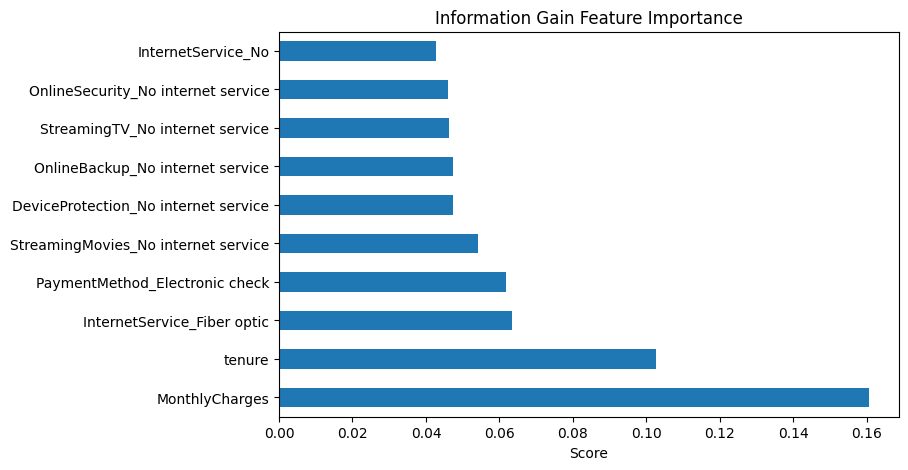

In [56]:
#FEATURE SELECTION (INFORMATION GAIN)
mi_scores = mutual_info_classif(X_train, y_train)

mi_result = pd.Series(mi_scores, index=X.columns)

mi_result.sort_values(ascending=False).head(10).plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Information Gain Feature Importance")
plt.xlabel("Score")
plt.show()

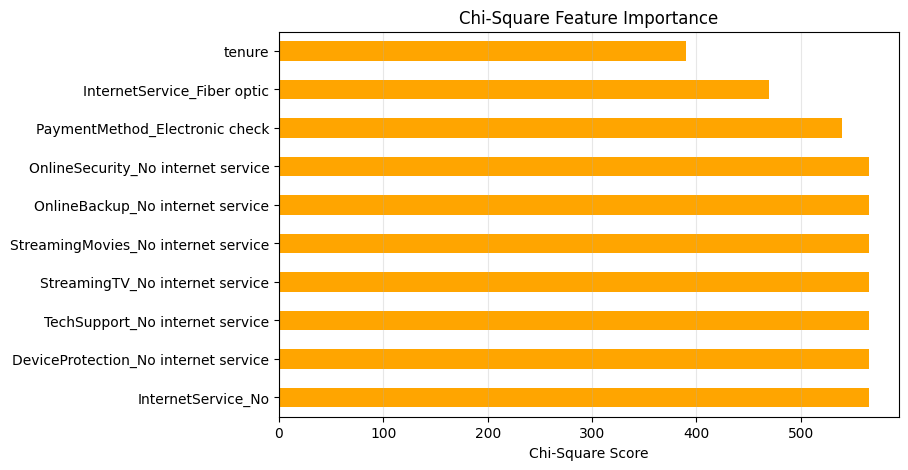

In [57]:
#CHI-SQUARE FEATURE SELECTION
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# Scaling khusus Chi-Square
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Hitung skor Chi-Square
chi_scores, p_values = chi2(X_train_scaled, y_train)

# Convert ke Series
chi_result = pd.Series(
    chi_scores,
    index=X.columns
)

# Visualisasi
plt.figure(figsize=(8,5))

chi_result.sort_values(ascending=False).head(10).plot(
    kind='barh',
    color='orange'
)

plt.title("Chi-Square Feature Importance")
plt.xlabel("Chi-Square Score")

plt.grid(axis='x', alpha=0.3)

plt.show()

Berdasarkan hasil seleksi fitur menggunakan Information Gain dan Chi Square, fitur yang paling berpengaruh terhadap prediksi churn pelanggan adalah MonthlyCharges, tenure, InternetService_Fiber optic, serta PaymentMethod_Electronic check. Selain itu, beberapa fitur yang berkaitan dengan status layanan internet juga menunjukkan hubungan yang kuat terhadap variabel churn. Hasil ini menunjukkan bahwa biaya layanan, lama berlangganan, jenis layanan internet, dan metode pembayaran merupakan faktor utama yang perlu diperhatikan dalam analisis churn pelanggan.

In [58]:
#Random Forest
clf_forest = RandomForestClassifier(n_estimators=100, max_depth=10)
clf_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [59]:
pred = clf_forest.predict(X_train)

In [60]:
accuracy_score(y_train, pred)

0.8865668035757429

[[3440  690]
 [ 249 3899]]


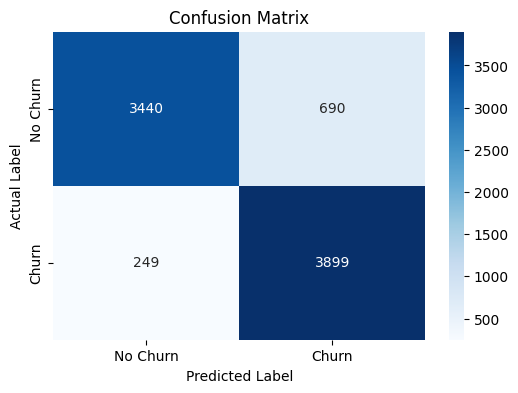

In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, pred)
print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [62]:
pred_test = clf_forest.predict(X_test)
accuracy_score(y_test, pred_test)

0.8449275362318841

Model Random Forest dengan parameter max_depth=10 menghasilkan nilai accuracy sebesar 88% pada data training dan 84% pada data testing. Selisih akurasi sebesar 4% menunjukkan adanya overfitting dalam tingkat yang ringan. Namun, perbedaan tersebut masih tergolong kecil sehingga model dapat dikatakan memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah digunakan selama proses pelatihan. Selain itu, penggunaan parameter max_depth=10 membantu membatasi kompleksitas pohon keputusan sehingga risiko overfitting dapat diminimalkan.

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1044
           1       0.80      0.91      0.85      1026

    accuracy                           0.84      2070
   macro avg       0.85      0.85      0.84      2070
weighted avg       0.85      0.84      0.84      2070



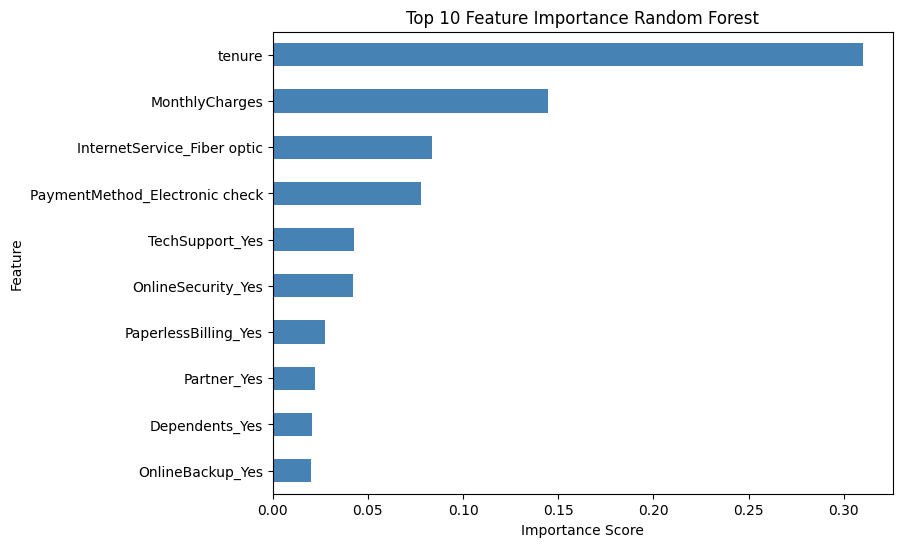

In [64]:
# Feature Importance

feature_importance = pd.Series(
    clf_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

feature_importance.head(10).sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title("Top 10 Feature Importance Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

Berdasarkan hasil Feature Importance dari algoritma Random Forest, diketahui bahwa tenure, MonthlyCharges,InternetService_Fiber optic, dan PaymentMethod_Electronic check merupakan fitur yang memberikan kontribusi terbesar dalam proses prediksi churn pelanggan. Hasil Feature Importance menunjukkan pola yang konsisten dengan analisis Information Gain dan Chi Square. Ketiga metode sama sama mengidentifikasi MonthlyCharges, tenure, InternetService_Fiber optic, dan PaymentMethod_Electronic check sebagai fitur yang paling berpengaruh terhadap churn pelanggan.

Business Interpretation

Berdasarkan hasil evaluasi model, Random Forest mampu mengklasifikasikan pelanggan yang berpotensi churn dengan tingkat akurasi sebesar 84 persen pada data testing. Selisih akurasi antara data training dan testing relatif kecil sehingga menunjukkan bahwa model memiliki kemampuan generalisasi yang baik dan tidak mengalami overfitting secara signifikan. Selain itu, hasil Feature Importance menunjukkan bahwa biaya layanan bulanan, lama berlangganan, jenis layanan internet Fiber Optic, dan metode pembayaran Electronic Check merupakan faktor yang paling memengaruhi prediksi churn. Dengan demikian, model tidak hanya mampu menghasilkan prediksi yang baik, tetapi juga memberikan informasi mengenai faktor faktor yang perlu menjadi perhatian perusahaan dalam mempertahankan pelanggan.